# AIVLE스쿨 2차 미니프로젝트: 신규 아파트 주차 수요 예측

<img src = "https://github.com/Jangrae/img/blob/master/parking.png?raw=true" width=800, align="left"/>

# 단계 2: 탐색적 데이터 분석

## [미션]

단계1 에서 생성한 데이터에 대해서 탐색적 분석을 수행합니다.

1) 단변량 분석
    - 숫자형, 범주형 변수에 맞게 데이터를 탐색하며 비즈니스적 의미를 파악합니다.
2) 이변량 분석
    - 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
    - 범주형 변수 → 실차량수 관계를 분석합니다.
3) 전처리(추가)
    - 범주형 변수 중에는 범줏값 개수가 적은 범주들은 유사한 범주끼리 묶어 봅니다.
    - 불필요한 변수를 제거합니다.

## 1. 환경설정

### (1) 로컬 수행(Anaconda)

- project 폴더에 필요한 파일들을 넣고, 본 파일을 열었다면, 별도 경로 지정이 필요하지 않습니다.

In [1248]:
# 기본 경로
path = './'

### (2) 구글 콜랩 수행

- 구글 콜랩을 사용중이면 구글 드라이브를 연결합니다.

### (3) 한글 폰트 표시용 라이브러리 설치

### (4) 라이브러리 불러오기

In [1253]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (5) 데이터 불러오기

- joblib.dump() 함수를 사용해 이전에 저장했던 base_data1.pkl 파일을 읽어옵니다.
- 읽어온 데이터를 apart 데이터프레임으로 선언합니다.

#### 1) 데이터 불러오기

In [1257]:
# 파일 불러오기
apart = joblib.load(path+'base_data1.pkl')

#### 2) 기본 정보 조회

In [1260]:
def basic_info(data):
    display(data.head())
    display(data.tail())

In [1262]:
basic_info(apart)

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
0,C0001,78,서울,2013,계단식,개별가스난방,전체동 설치,109,6023.7683,5.696200e+07,642930.000000,0,0,0,0,2,0,0
1,C0002,35,서울,2013,복도식,개별가스난방,전체동 설치,35,1569.1668,6.306200e+07,470100.000000,0,2,0,0,0,0,0
2,C0003,88,서울,2013,계단식,개별가스난방,전체동 설치,88,7180.1396,7.219000e+07,586540.000000,0,0,0,0,4,0,0
3,C0004,477,서울,2014,복도식,지역난방,전체동 설치,943,47058.9273,1.015167e+08,950305.000000,0,0,0,0,1,0,2
4,C0006,15,서울,2013,복도식,개별가스난방,전체동 설치,21,543.0268,5.522750e+07,340148.333333,3,3,0,0,0,0,0


,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
340,C0354,1485,대전충남,1993,복도식,중앙난방,전체동 설치,298,64622.2500,7.595571e+06,104975.714286,0,5,1,0,1,0,0
341,C1354,1386,대전충남,1993,복도식,중앙가스난방,전체동 설치,258,57616.8100,8.092875e+06,111848.750000,0,4,1,0,3,0,0
342,C0356,956,경기,1994,복도식,지역가스난방,전체동 설치,243,37398.7200,9.931000e+06,134540.000000,0,1,0,0,0,0,0
343,C0358,120,강원,2020,복도식,개별가스난방,전체동 설치,47,5581.8024,2.515500e+06,50040.000000,0,1,1,0,0,0,0
344,C0359,447,대구경북,1994,복도식,중앙유류난방,전체동 설치,78,19383.4100,7.628000e+06,125010.000000,0,1,1,0,0,0,0


## 2. 기본 분석

- 기술통계정보, 결측치 확인 등 기본 분석을 수행합니다.

In [1265]:
apart.isna().sum()

단지코드       0
총세대수       0
지역         0
준공연도       0
건물형태       0
난방방식       0
승강기설치여부    0
실차량수       0
총면적        0
임대보증금      0
임대료        0
면적10_20    0
면적20_30    0
면적30_40    0
면적40_50    0
면적50_60    0
면적60_70    0
면적70_80    0
dtype: int64

In [1267]:
apart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   단지코드     345 non-null    object 
 1   총세대수     345 non-null    int64  
 2   지역       345 non-null    object 
 3   준공연도     345 non-null    int64  
 4   건물형태     345 non-null    object 
 5   난방방식     345 non-null    object 
 6   승강기설치여부  345 non-null    object 
 7   실차량수     345 non-null    int64  
 8   총면적      345 non-null    float64
 9   임대보증금    345 non-null    float64
 10  임대료      345 non-null    float64
 11  면적10_20  345 non-null    int64  
 12  면적20_30  345 non-null    int64  
 13  면적30_40  345 non-null    int64  
 14  면적40_50  345 non-null    int64  
 15  면적50_60  345 non-null    int64  
 16  면적60_70  345 non-null    int64  
 17  면적70_80  345 non-null    int64  
dtypes: float64(3), int64(10), object(5)
memory usage: 48.6+ KB


In [1269]:
apart.describe()

,총세대수,준공연도,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
count,345.000000,345.000000,345.000000,345.000000,3.450000e+02,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,546.759420,2007.713043,555.431884,37282.661962,2.382737e+07,197729.050210,0.011594,0.272464,0.901449,0.742029,0.831884,0.011594,0.159420
std,432.359538,7.261036,374.640474,29588.197927,2.247481e+07,158760.777669,0.170103,0.678551,1.097896,0.982463,1.303226,0.170103,0.528908
min,1.000000,1992.000000,21.000000,68.930000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178.000000,2003.000000,258.000000,11293.832100,1.272491e+07,112905.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,491.000000,2008.000000,498.000000,32190.360000,1.930850e+07,172000.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,853.000000,2013.000000,822.000000,56189.979600,2.837700e+07,227564.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,2289.000000,2022.000000,1657.000000,150126.863200,1.898219e+08,950305.000000,3.000000,5.000000,8.000000,8.000000,8.000000,3.000000,3.000000


## 3. 단변량 분석

- 주요 변수들을 연속형, 범주형으로 구분하여 데이터 분포를 살펴보며 비즈니스적인 의미를 파악합니다.
    - 연속형: '실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금'
    - 범주형: '지역', '건물형태', '난방방식', '승강기설치여부'
- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제한 후 분석합니다.

### (1) 연속형 변수

- 대상: '실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금'
- 기술통계, Histogram, Boxplot 등을 사용해 데이터 분포를 파악합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [1273]:
col_num = ['실차량수', '총세대수', '총면적', '준공연도', '임대료', '임대보증금']

In [1275]:
# 함수 만들기
def single_var_float(data, col):
    des = data.describe()
    mean_ = des[col].loc['mean']
    std_ = des[col].loc['std']
    min_ = des[col].loc['min']
    max_ = des[col].loc['max']
    print(f'mean: {mean_}')
    print(f'stdev: {std_}')
    print(f'minimum: {min_}')
    print(f'maximum: {max_}')
    plt.figure()
    plt.hist(data[col], bins=10)
    plt.show()
    plt.figure()
    sns.boxenplot(data[col])
    plt.show()

#### 1) 실차량수

mean: 555.431884057971
stdev: 374.64047358176344
minimum: 21.0
maximum: 1657.0


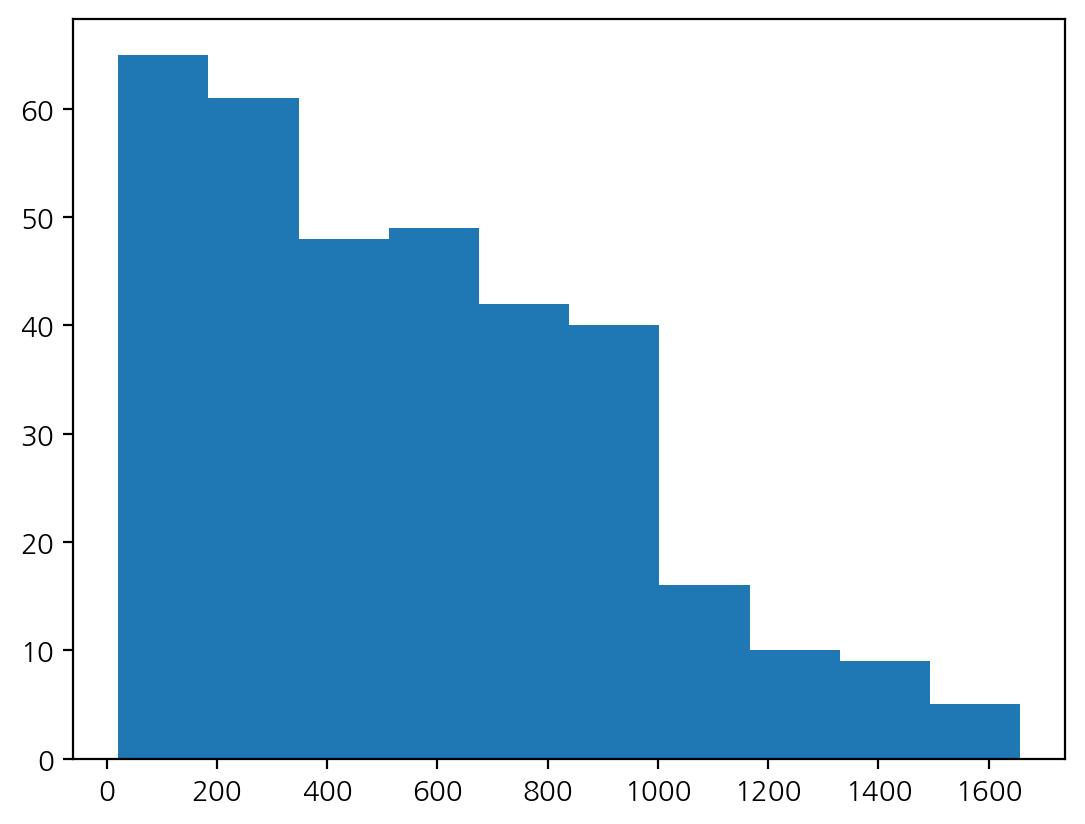

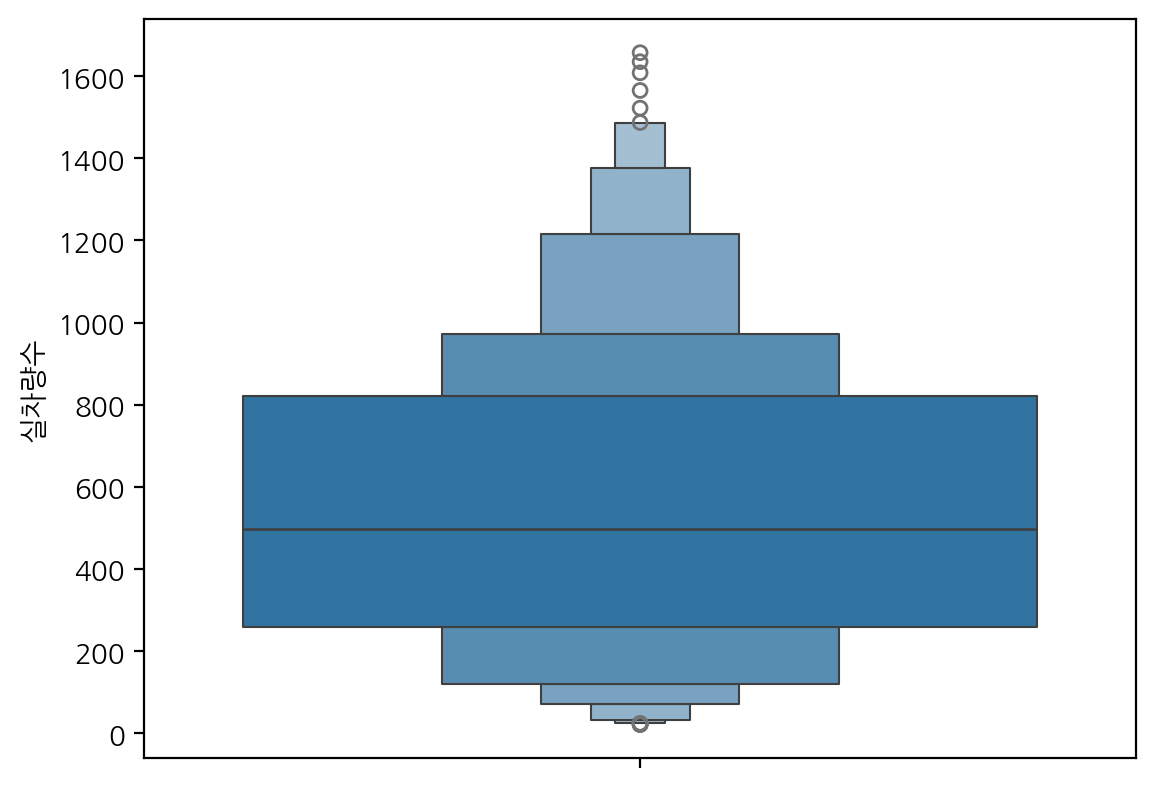

In [1278]:
single_var_float(apart, '실차량수')

#### 2) 총세대수

mean: 546.759420289855
stdev: 432.3595383954464
minimum: 1.0
maximum: 2289.0


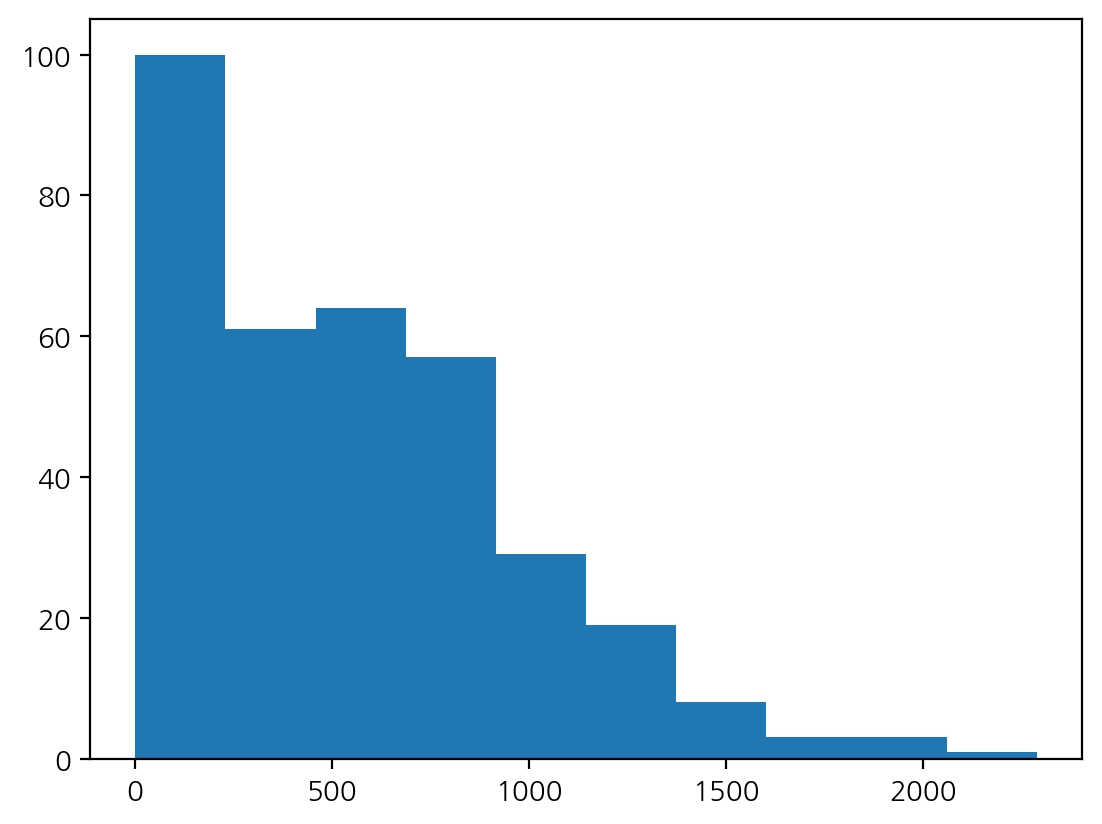

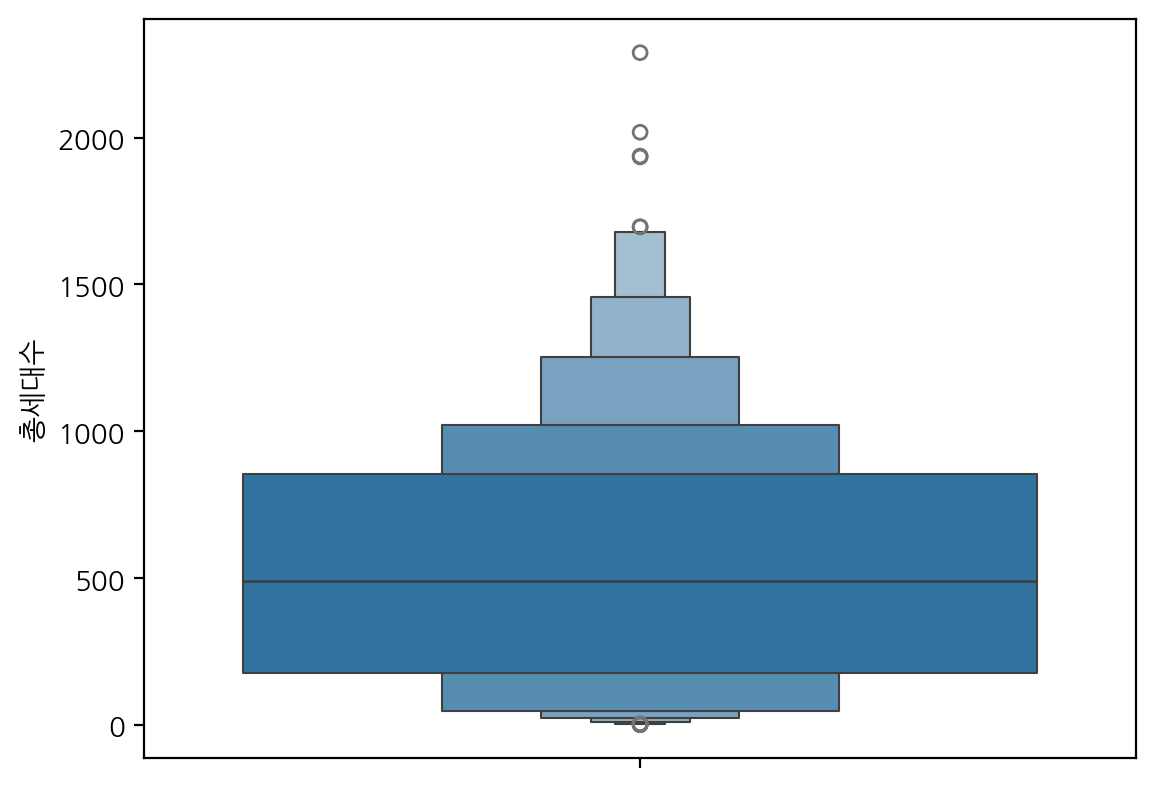

In [1281]:
single_var_float(apart, '총세대수')

#### 3) 총면적

mean: 37282.66196231884
stdev: 29588.19792702776
minimum: 68.92999999999999
maximum: 150126.86320000002


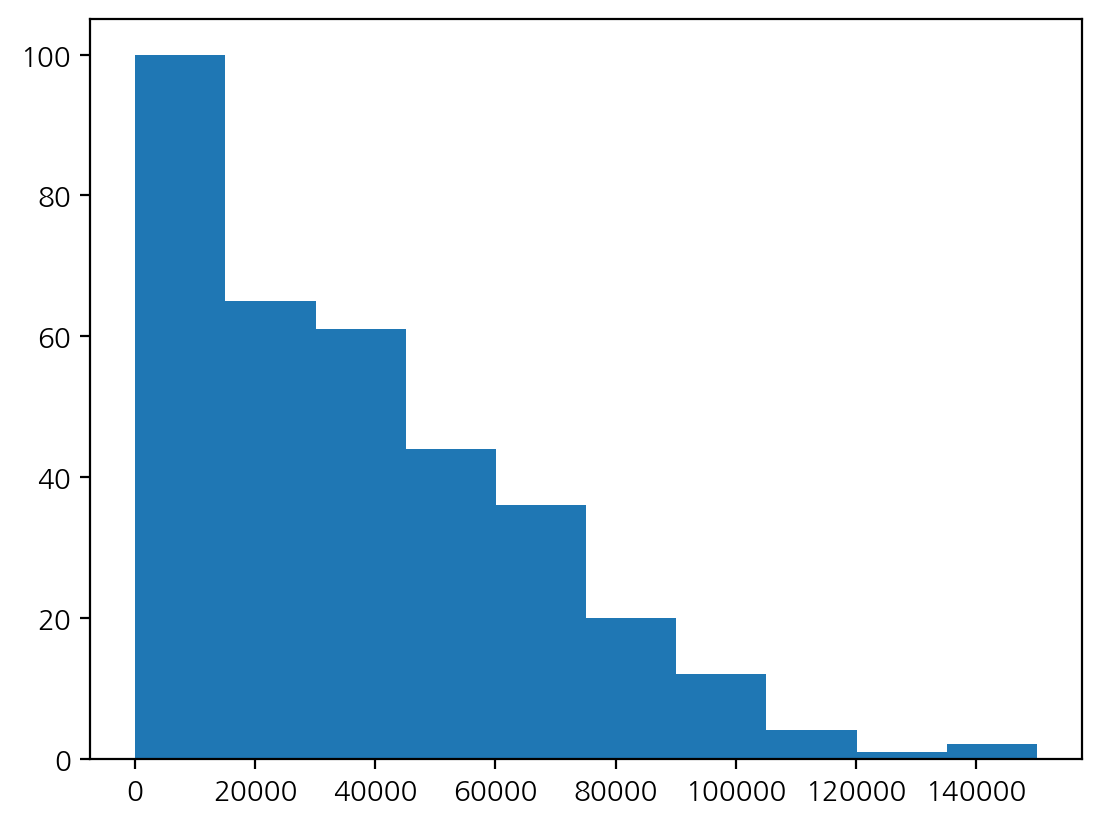

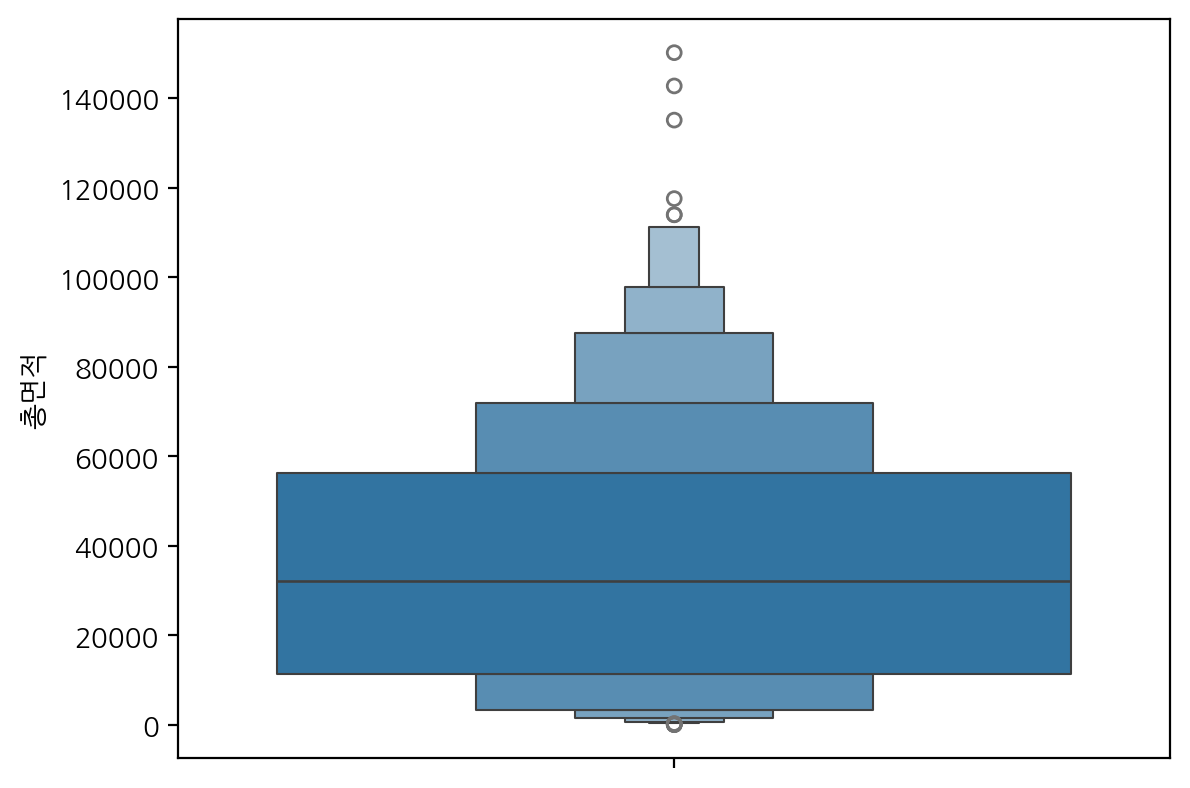

In [1283]:
single_var_float(apart, '총면적')

#### 4) 준공연도

mean: 2007.713043478261
stdev: 7.261036368215346
minimum: 1992.0
maximum: 2022.0


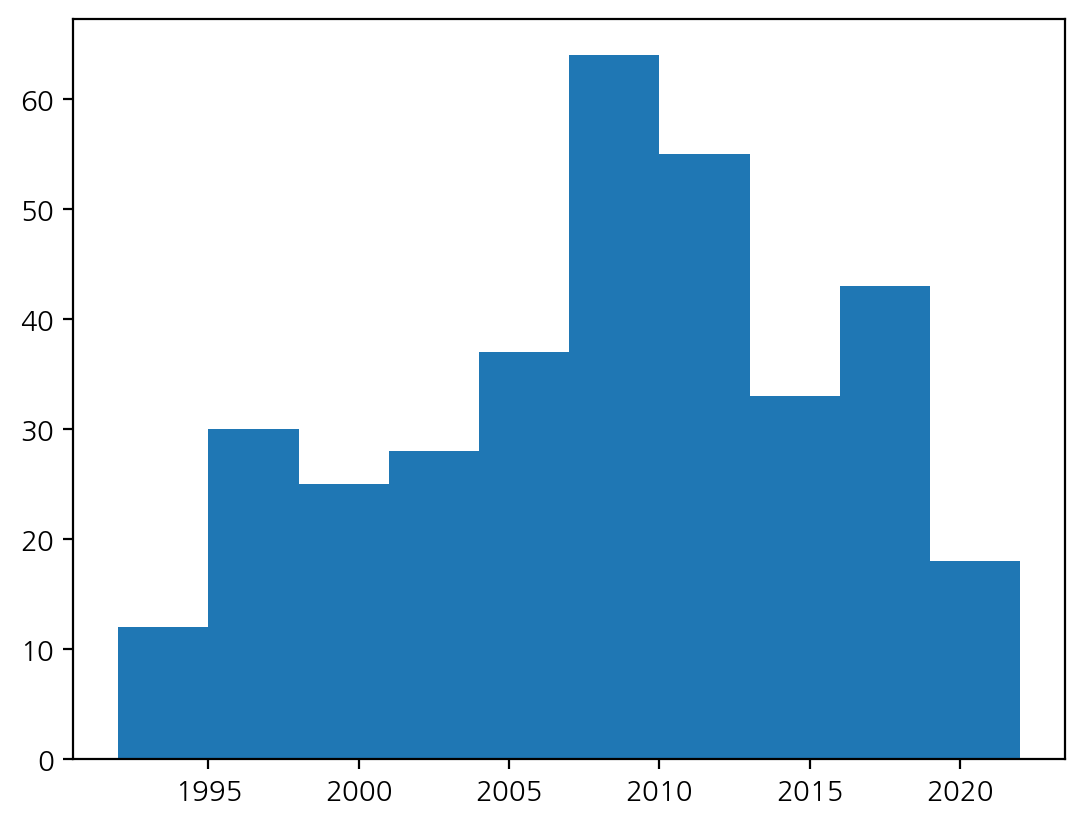

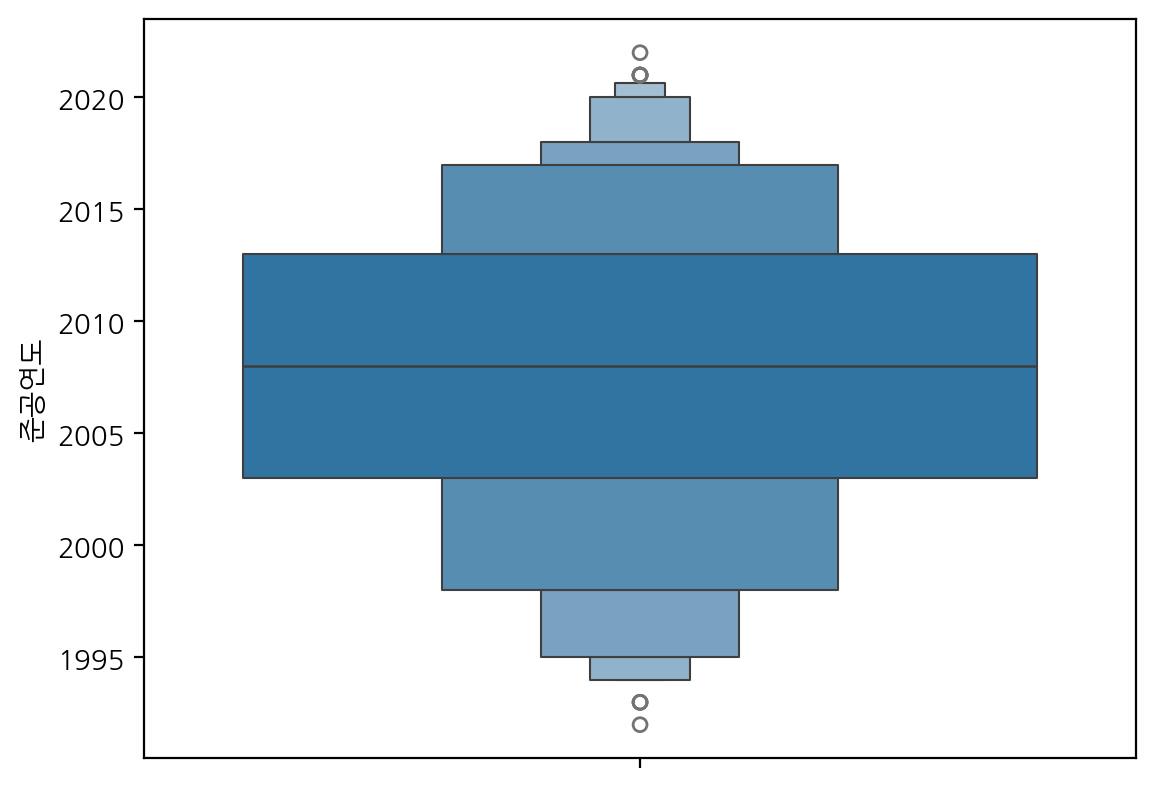

In [1286]:
single_var_float(apart, '준공연도')

#### 5) 임대료

mean: 197729.05021025677
stdev: 158760.7776694578
minimum: 0.0
maximum: 950305.0


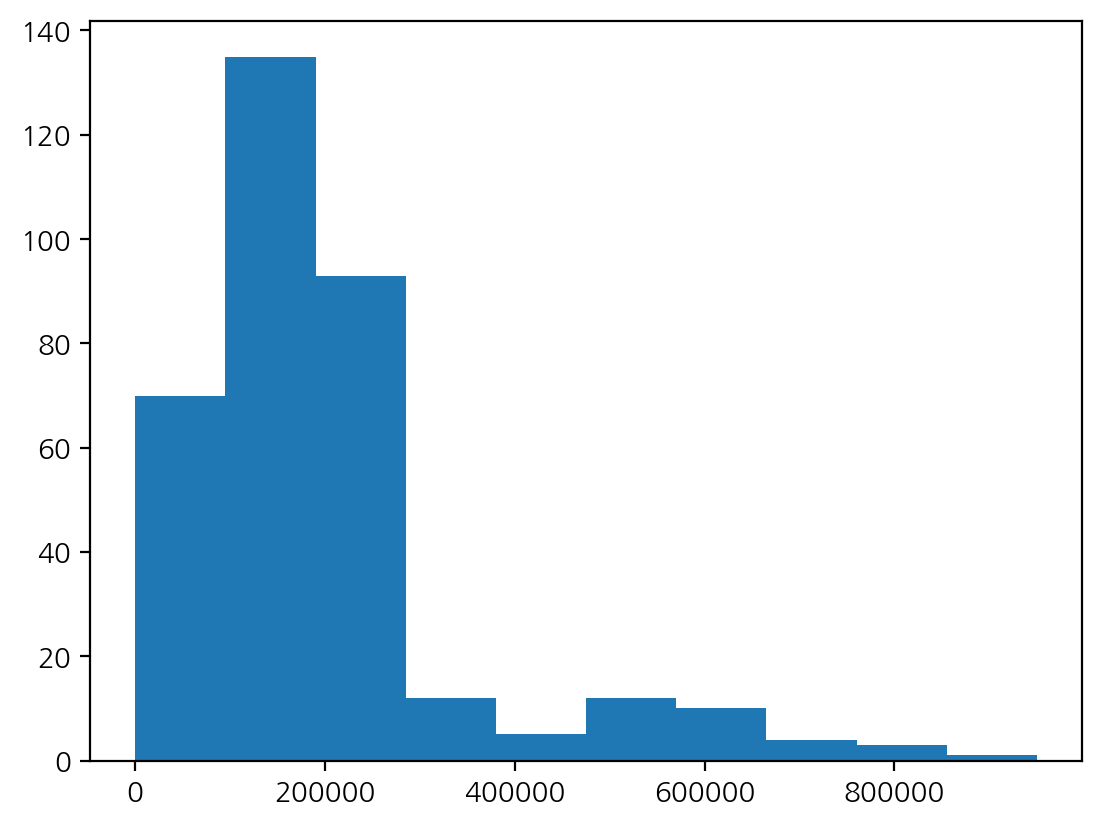

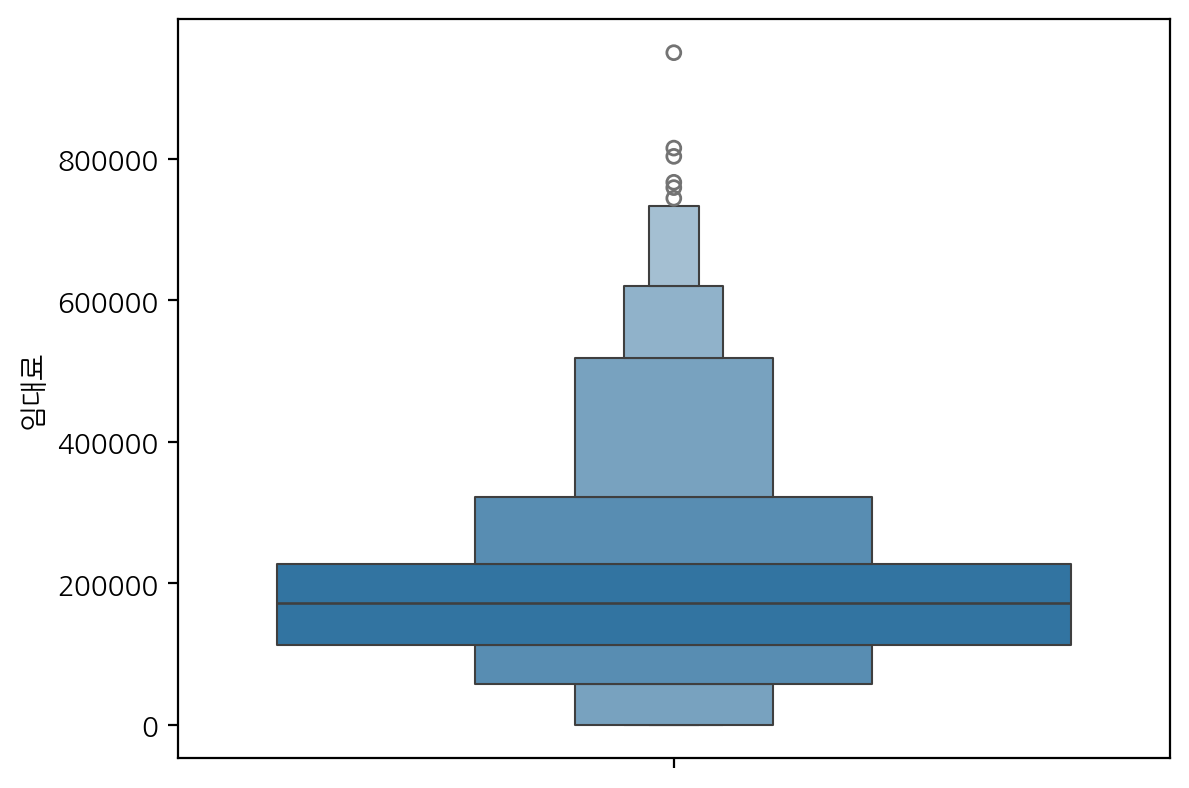

In [1288]:
single_var_float(apart, '임대료')

#### 6) 임대보증금

mean: 23827365.612961914
stdev: 22474806.841496356
minimum: 0.0
maximum: 189821857.14285713


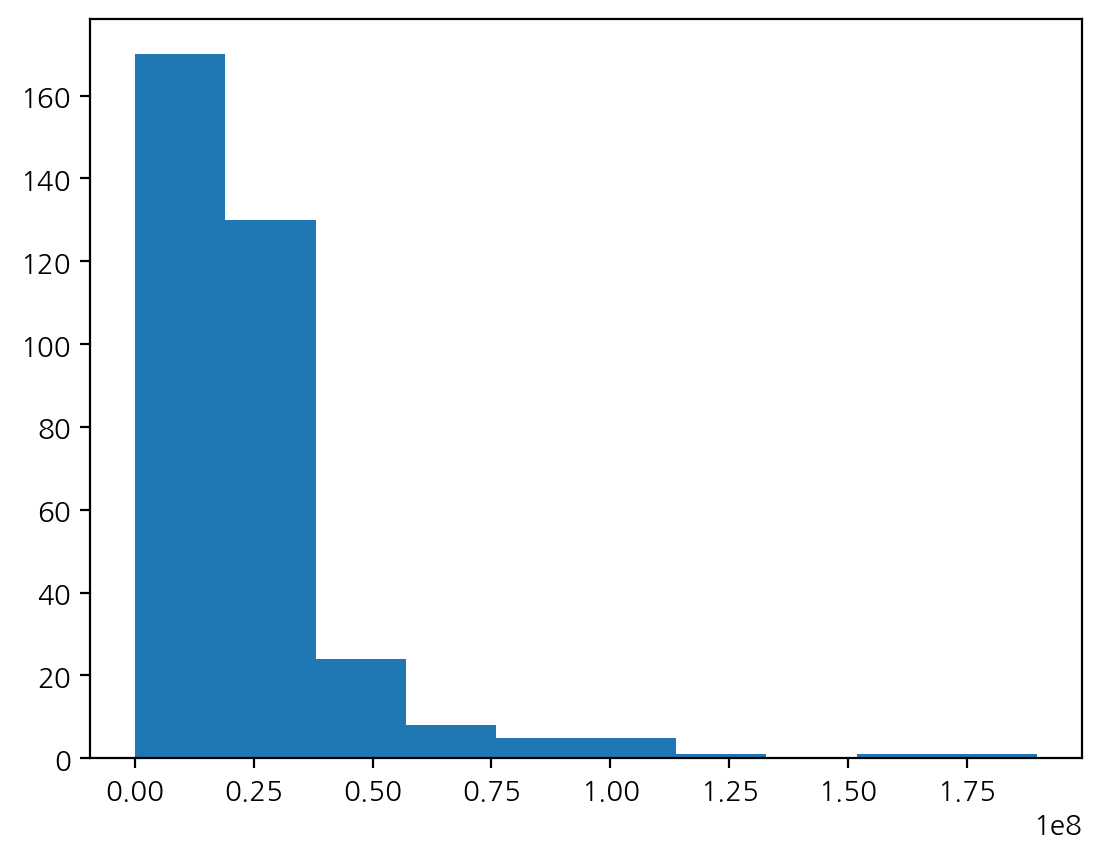

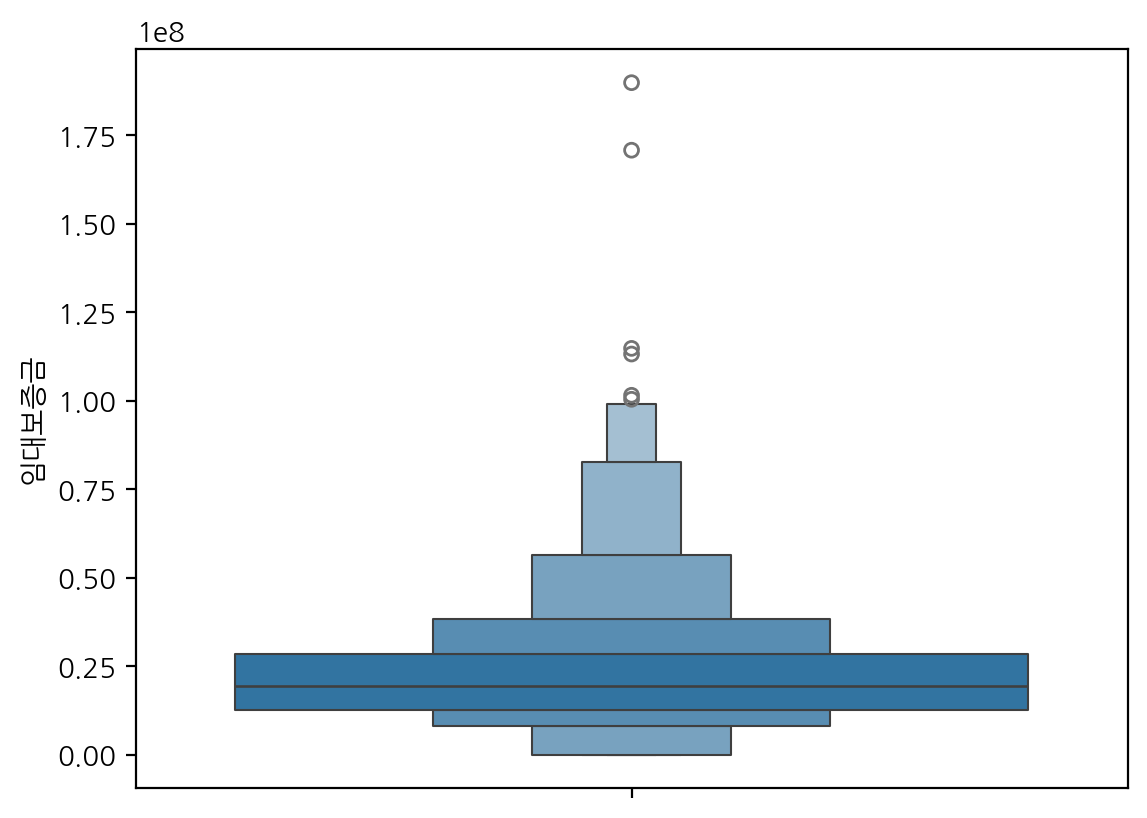

In [1291]:
single_var_float(apart, '임대보증금')

### (2) 범주형 변수

- 대상: '지역', '건물형태', '난방방식', '승강기설치여부'
- sns.countplot() 함수 등을 사용해 데이터 분포를 확인합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [1293]:
col_cat = ['지역', '건물형태', '난방방식', '승강기설치여부']

In [1295]:
# 함수 만들기
def single_var_cat(data, col):
    sns.countplot(data[col])
    plt.show()

#### 1) 지역

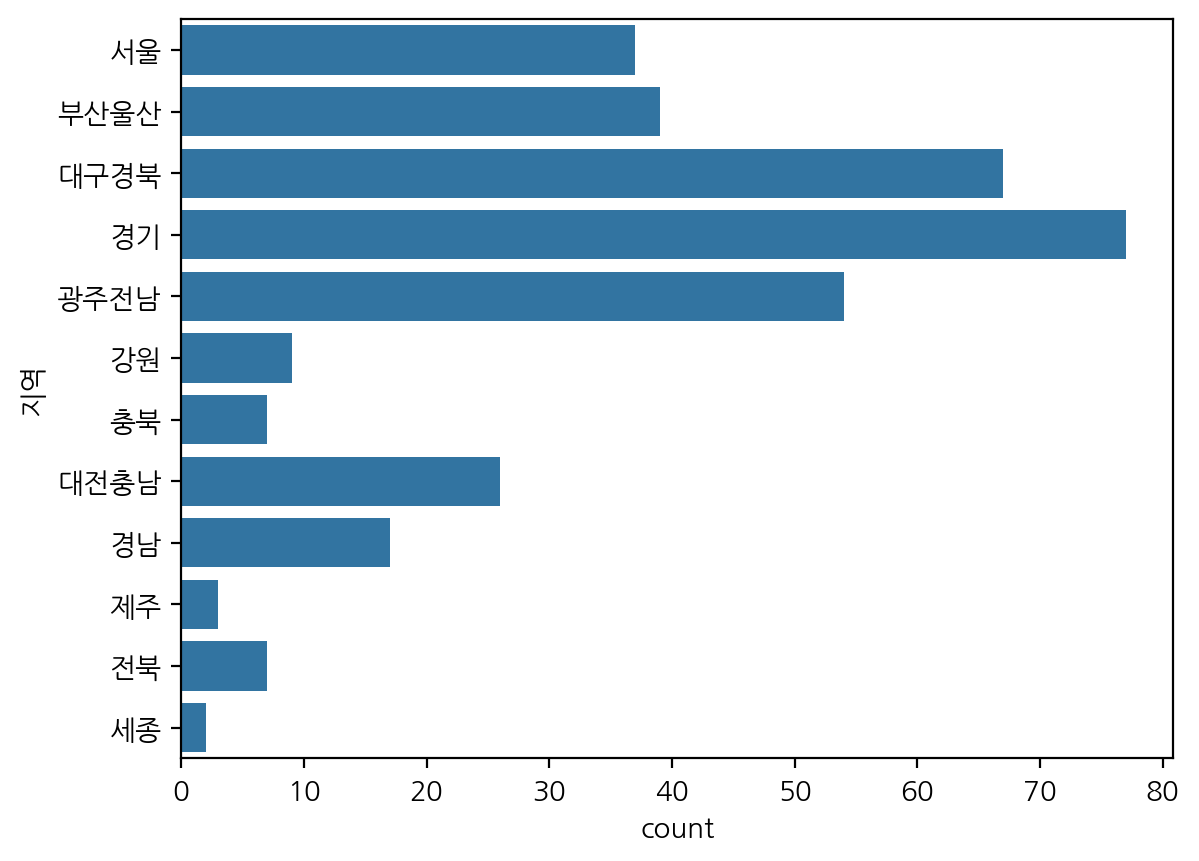

In [1297]:
single_var_cat(apart, '지역')

#### 2) 건물형태

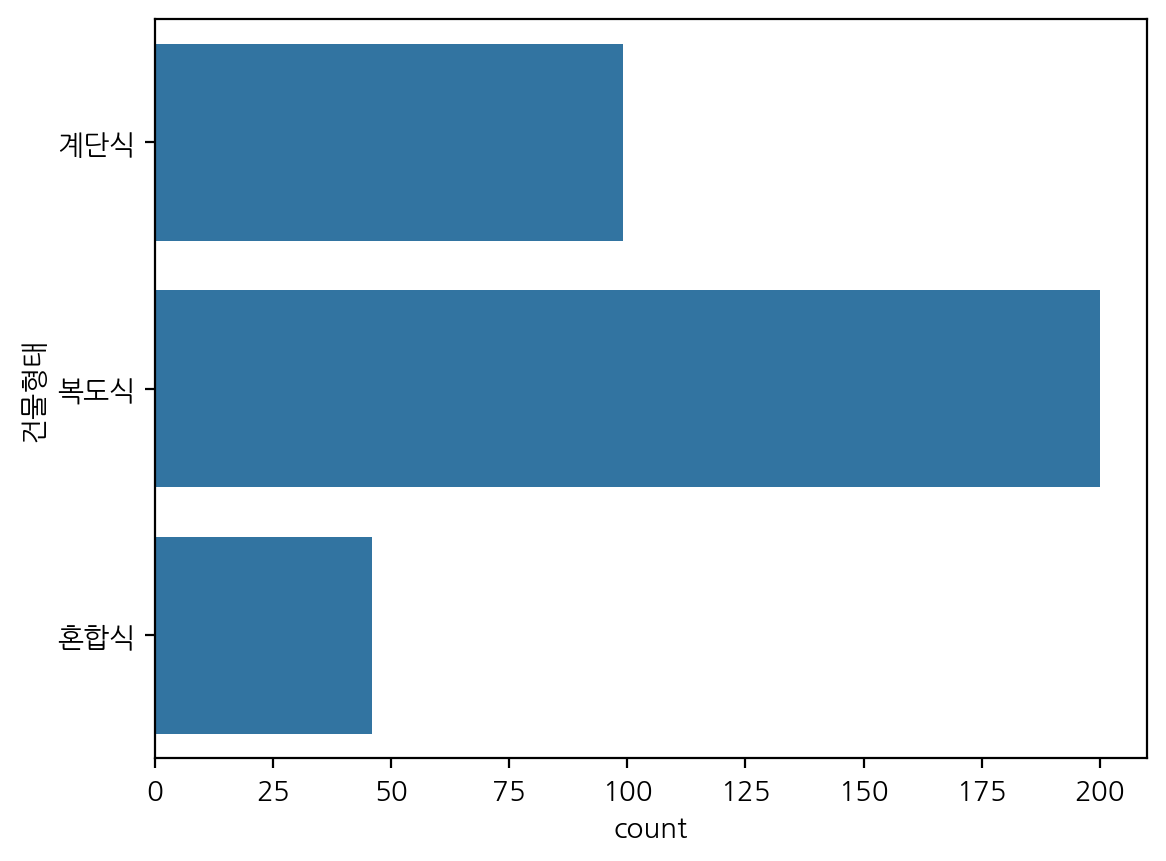

In [1300]:
single_var_cat(apart, '건물형태')

#### 3) 난방방식

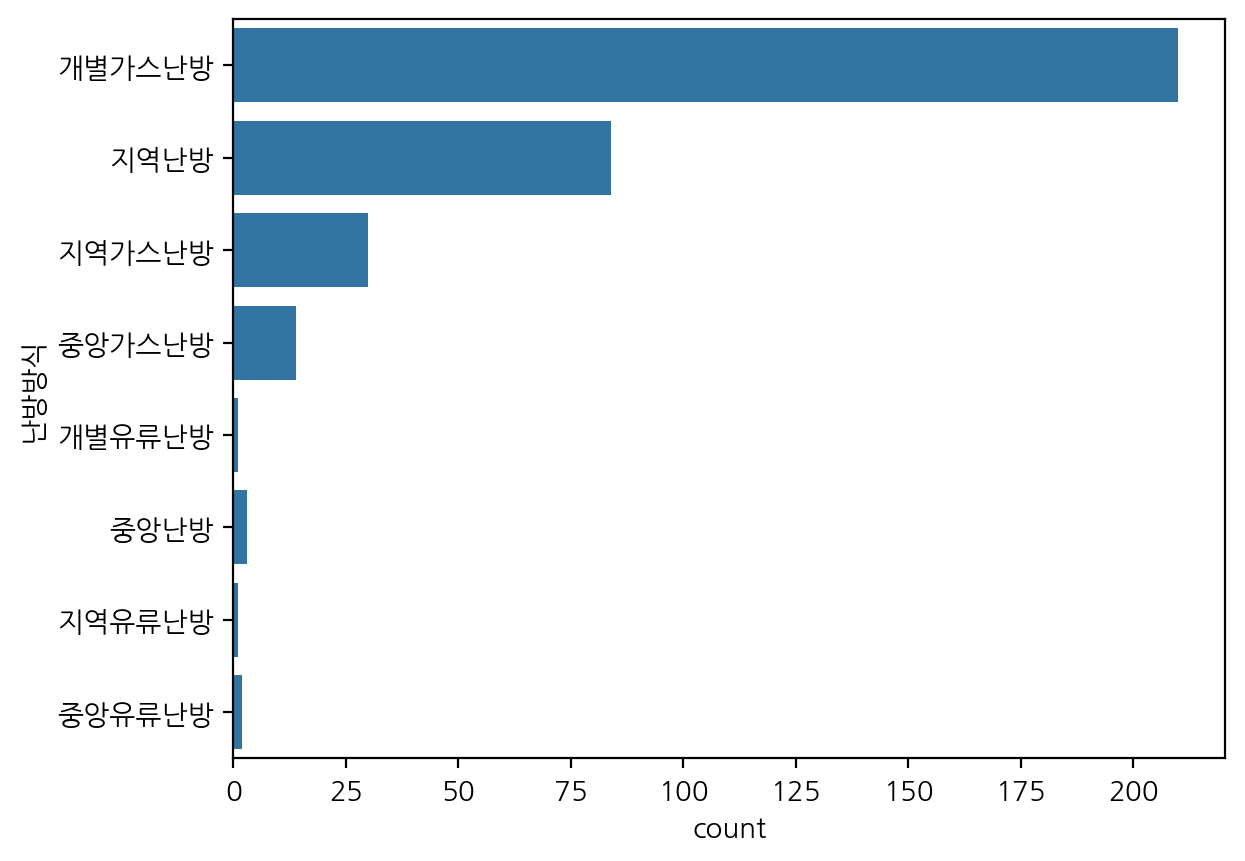

In [1302]:
single_var_cat(apart, '난방방식')

#### 4) 승강기설치여부

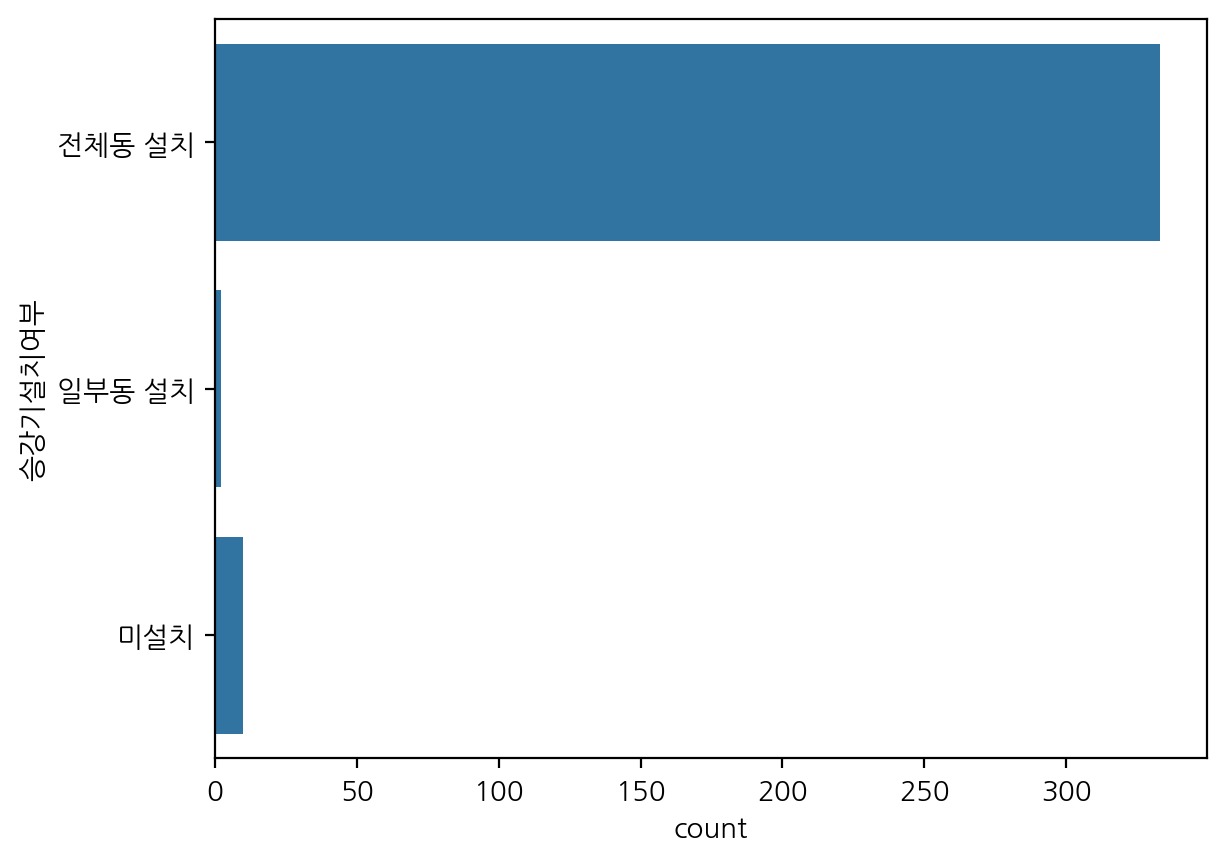

In [1307]:
single_var_cat(apart, '승강기설치여부')

#### 5) 전용면적구간

- 전용면적구간은 pd.melt() 함수를 사용해 pivot을 해제하여 전용면적구간별 세대수를 분석합니다.

In [1313]:
bins = [10, 20, 30, 40, 50, 60, 70, 80]
labels = [f'면적{bins[i]}_{bins[i+1]}' for i in range(0, len(bins)-1)]
labels_ = labels + ['단지코드']
temp = apart[labels_]
temp = temp.melt(id_vars='단지코드', value_vars=labels, ignore_index=False)
#df_melt = df_pivot.melt(id_vars=labels, value_vars=labels)
#df_melt
temp = temp.loc[temp['value']>0]
temp_df = pd.DataFrame()
temp_list = []
for i in range(0, len(temp)):
    var = temp['variable'].iloc[i]
    val = temp['value'].iloc[i]
    for j in range(0, val):
        temp_list.append(var)
temp_df['전용면적구간'] = temp_list

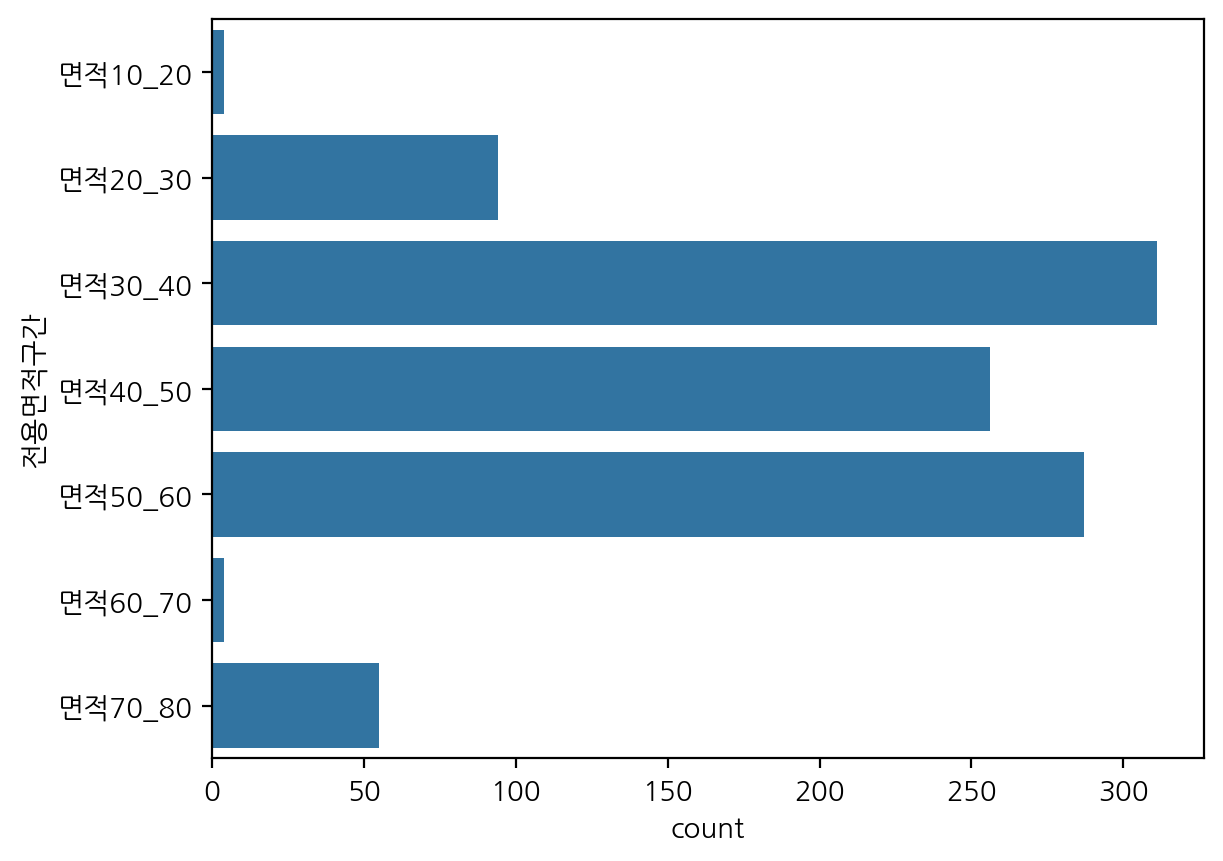

In [1315]:
single_var_cat(temp_df, '전용면적구간')

## 4. 이변량 분석

- 숫자형 변수들 간의 상관관계를 분석합니다.
- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 볌주형 변수 → 실차량수 관계를 분석합니다.

### (1) 숫자형 변수들 간의 상관관계

- 숫자형 변수 → 실차량수 상관관계를 분석합니다.    
- 숫자형 변수들 간의 상관관계를 df.corr() 메서드와 sns.heatmap() 함수 등을 사용해 시각화 합니다.

<Axes: >

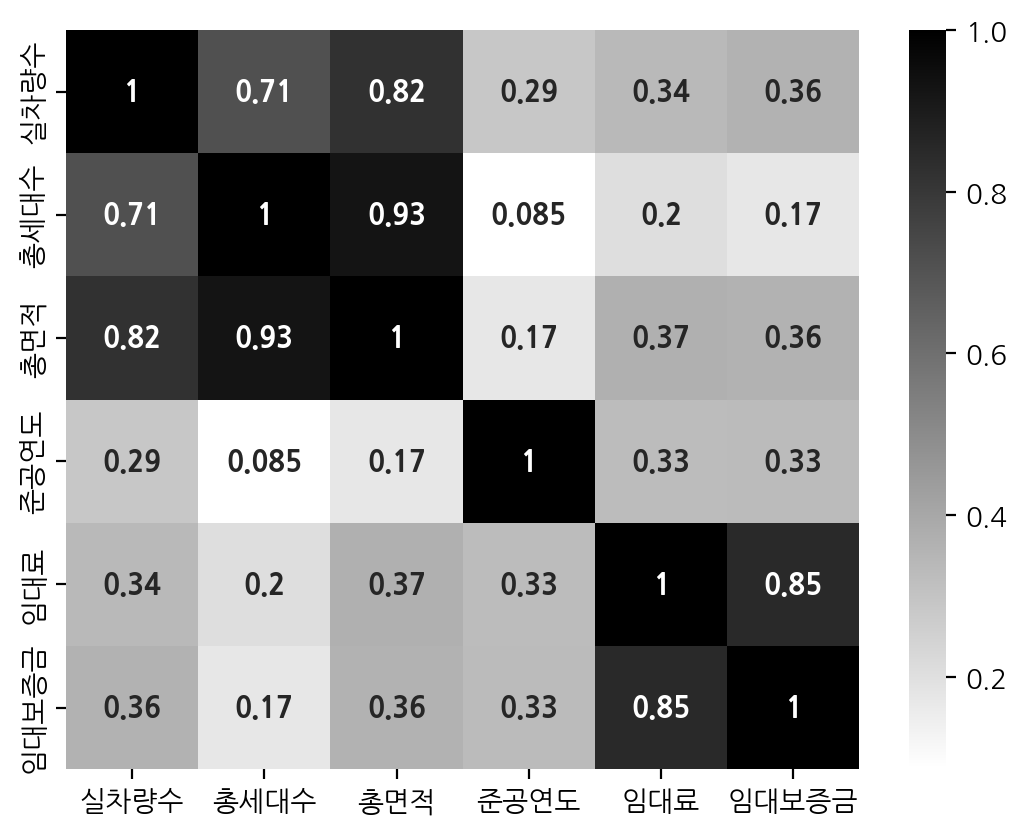

In [1319]:
apart_num = apart[col_num]
sns.heatmap(apart_num.corr(), annot=True, cmap='gray_r', annot_kws={'weight':'bold'})

### (2) 숫자형 변수 → 실차량수

- 상관계수가 높은 상위 3~5개 숫자형 변수와 실차량수 관계를 산점도를 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

In [1321]:
# 함수 만들기
def num_analysis(target, col, data):
    plt.figure(figsize=(5,5))
    plt.scatter(data[target], data[col])
    plt.xlabel(target)
    plt.ylabel(col)
    plt.show()

#### 1) 총면적

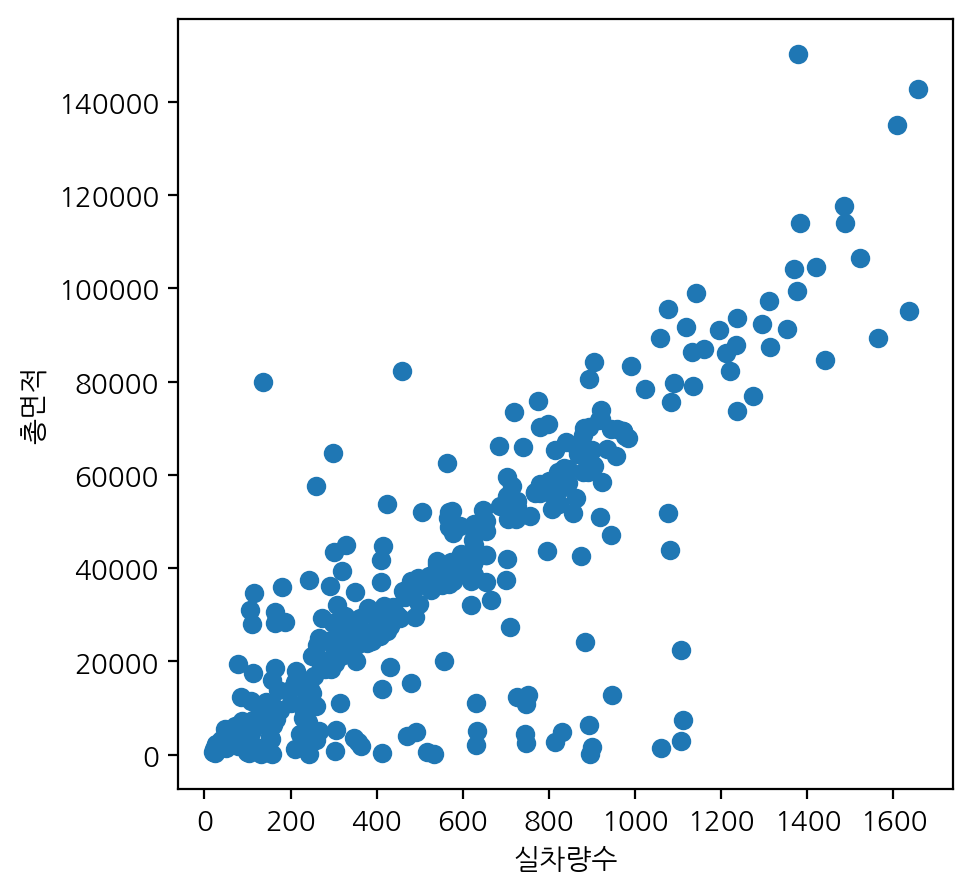

In [1325]:
num_analysis('실차량수', '총면적', apart)

#### 2) 총세대수

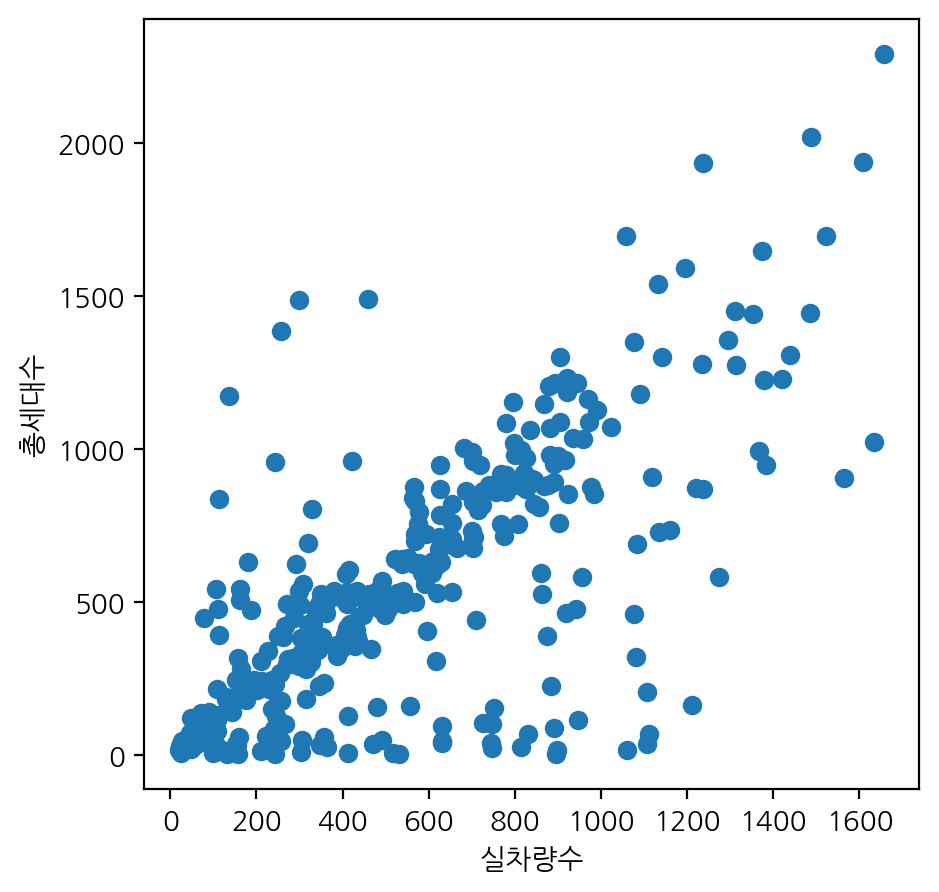

In [1328]:
num_analysis('실차량수', '총세대수', apart)

#### 3) 임대보증금

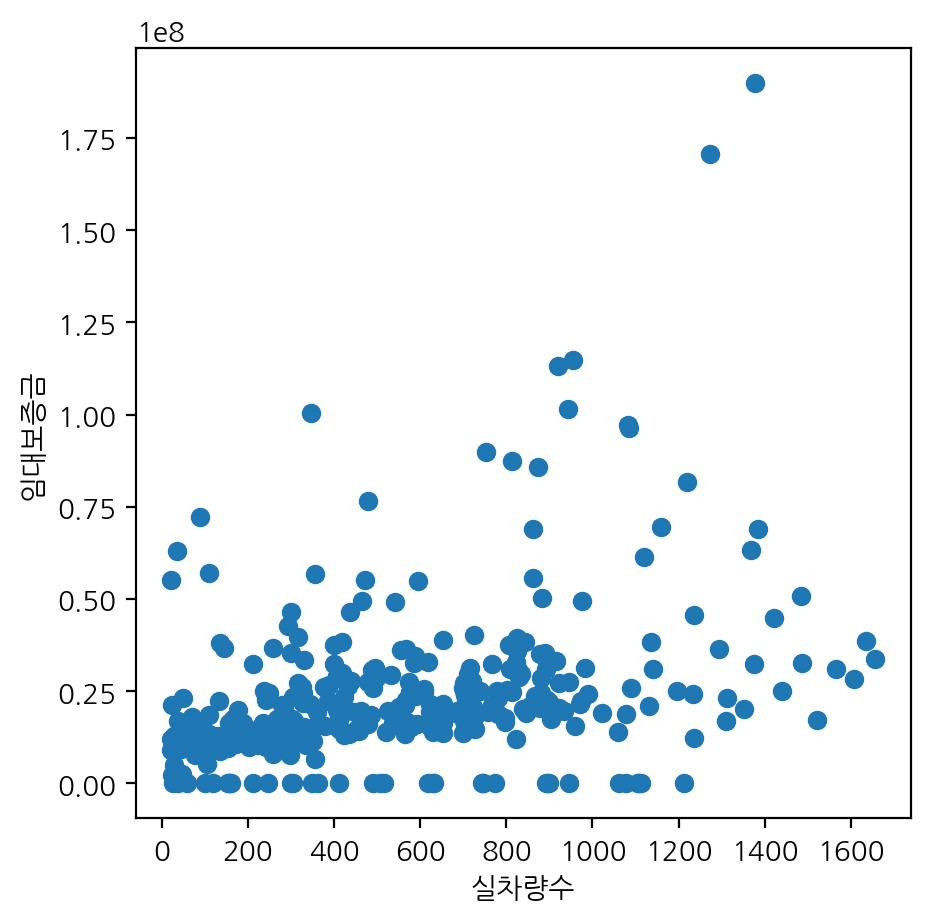

In [1331]:
num_analysis('실차량수', '임대보증금', apart)

#### 4) 임대료

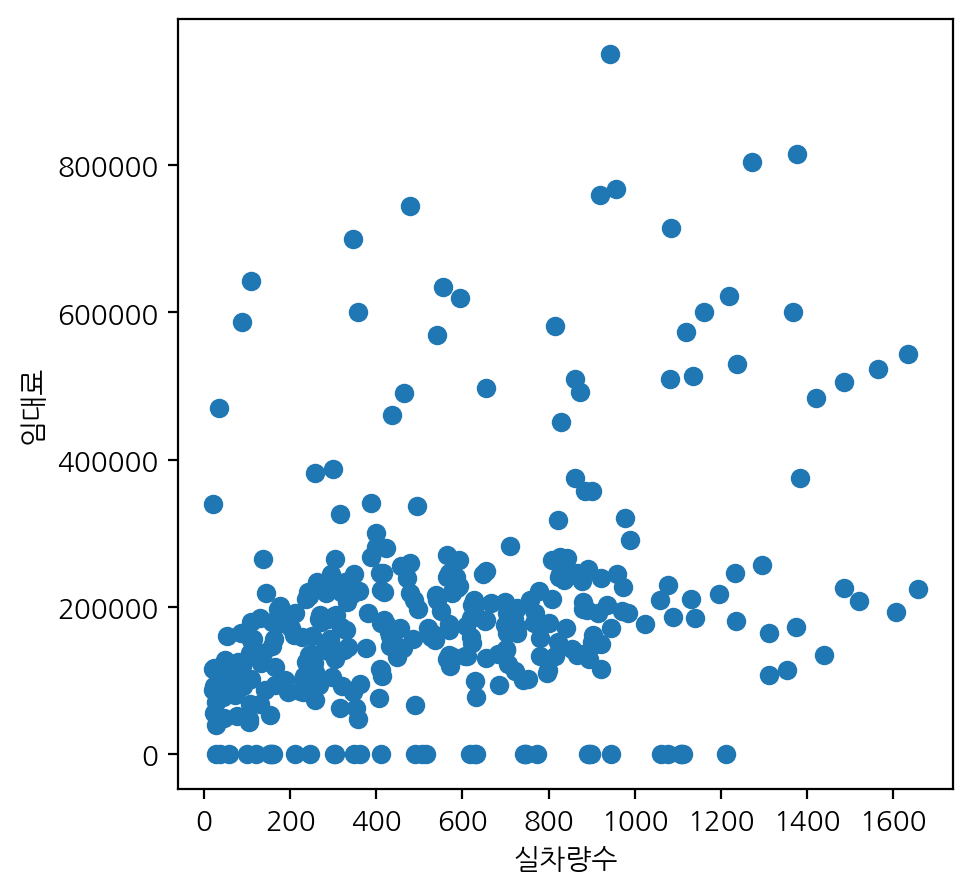

In [1334]:
num_analysis('실차량수', '임대료', apart)

#### 5) 준공연도

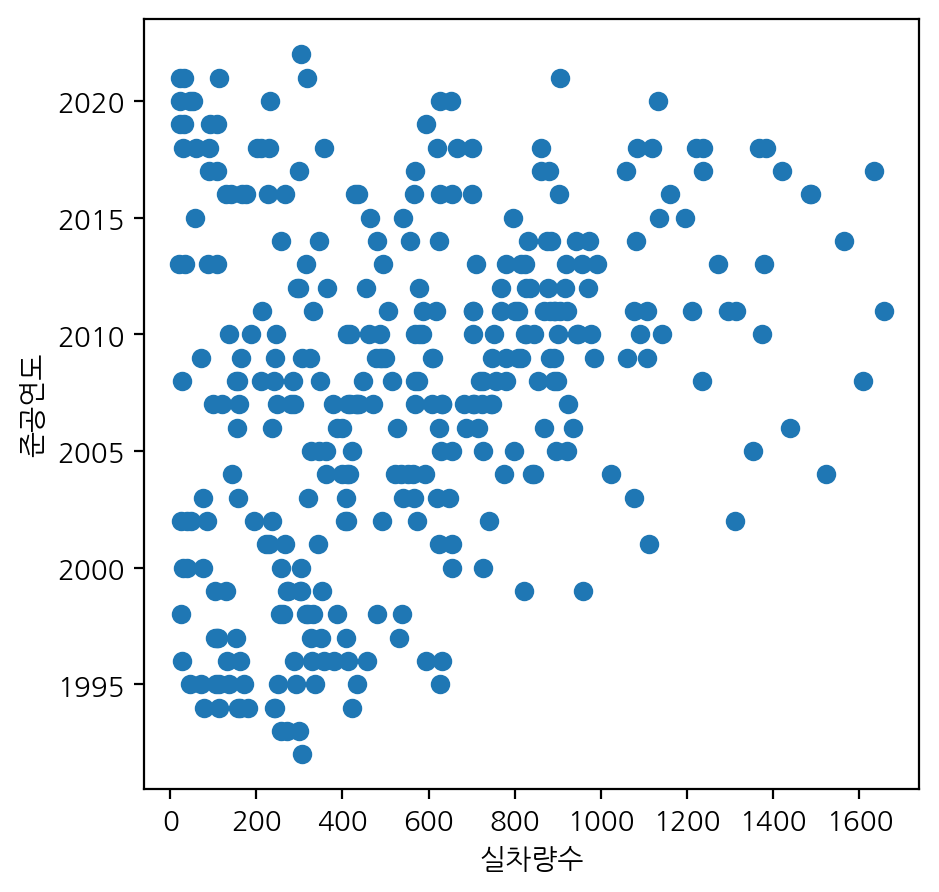

In [1337]:
num_analysis('실차량수', '준공연도', apart)

### (3) 범주형 변수 → 실차량수

- 범주형 변수 → 실차량수 관계를 분석합니다.
- 대상: '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부'
- 범줏값 별 실차량수 평균을 막대그래프로 시각화해 분석합니다.
- 반복되는 코드는 함수를 만들어 사용하면 편리합니다.

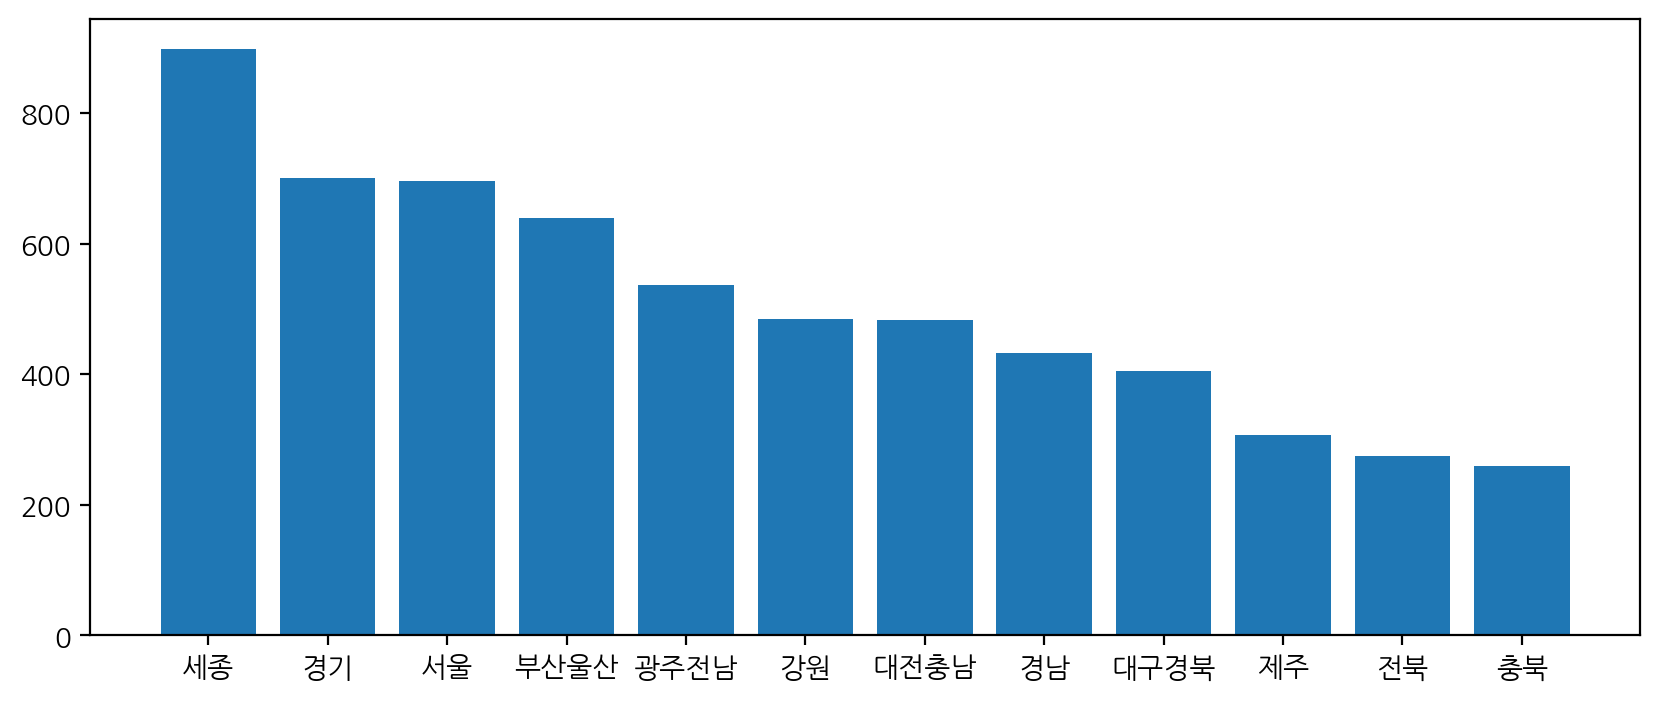

In [1340]:
# 함수 만들기
apart_cat = apart[['실차량수', '지역', '준공연도', '건물형태', '난방방식', '승강기설치여부']]
def cate_analysis(data, col):
    data_ = data.groupby(col, as_index=False)['실차량수'].mean()
    data_ = data_.sort_values(by='실차량수', ascending=False)
    plt.figure(figsize=(10,4))
    plt.bar(height = data_['실차량수'], x = data_[col])
    plt.show()
#return data_
cate_analysis(apart_cat, '지역')

#### 1) 지역

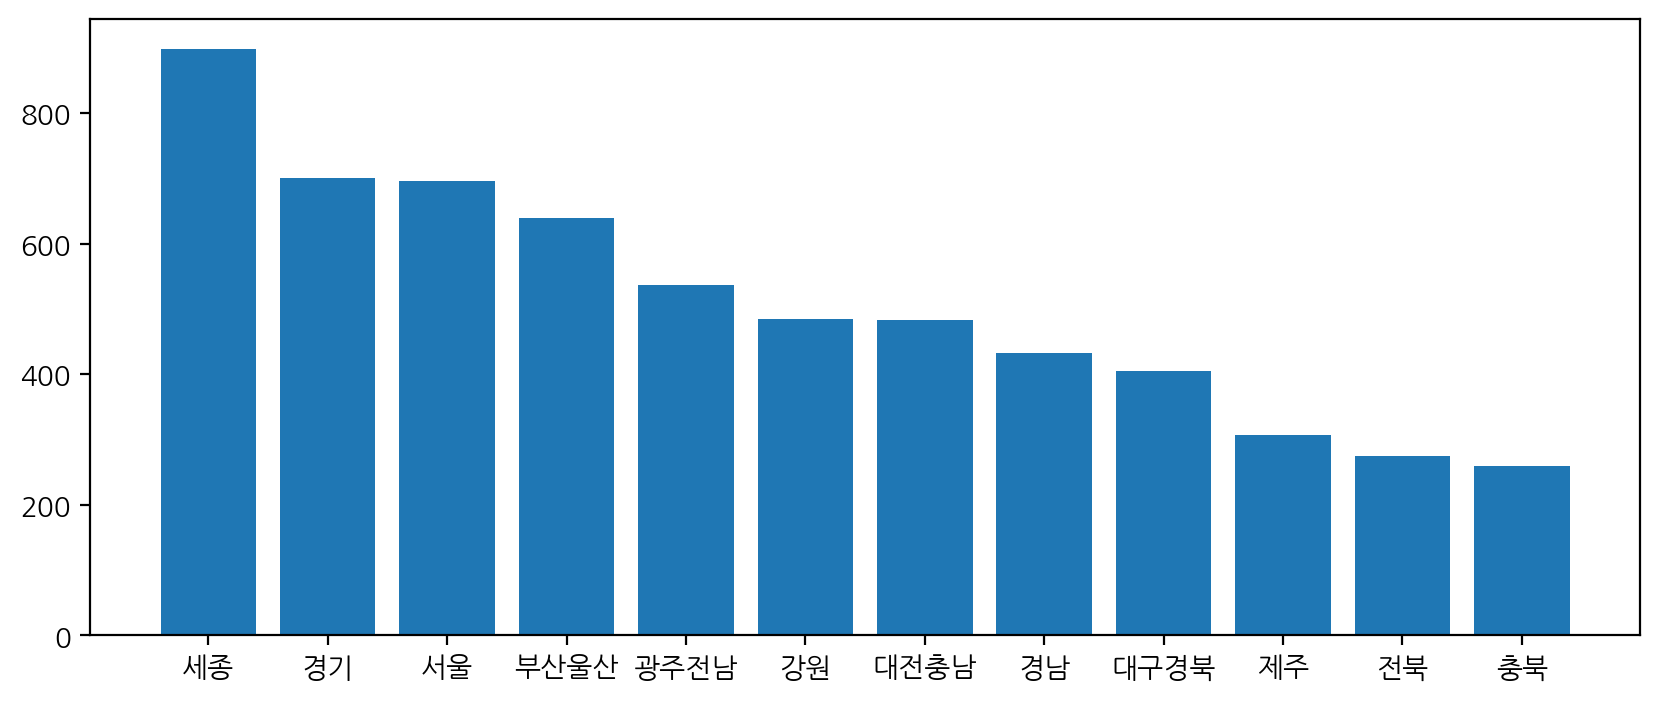

In [1343]:
cate_analysis(apart_cat, '지역')

#### 2) 준공연도

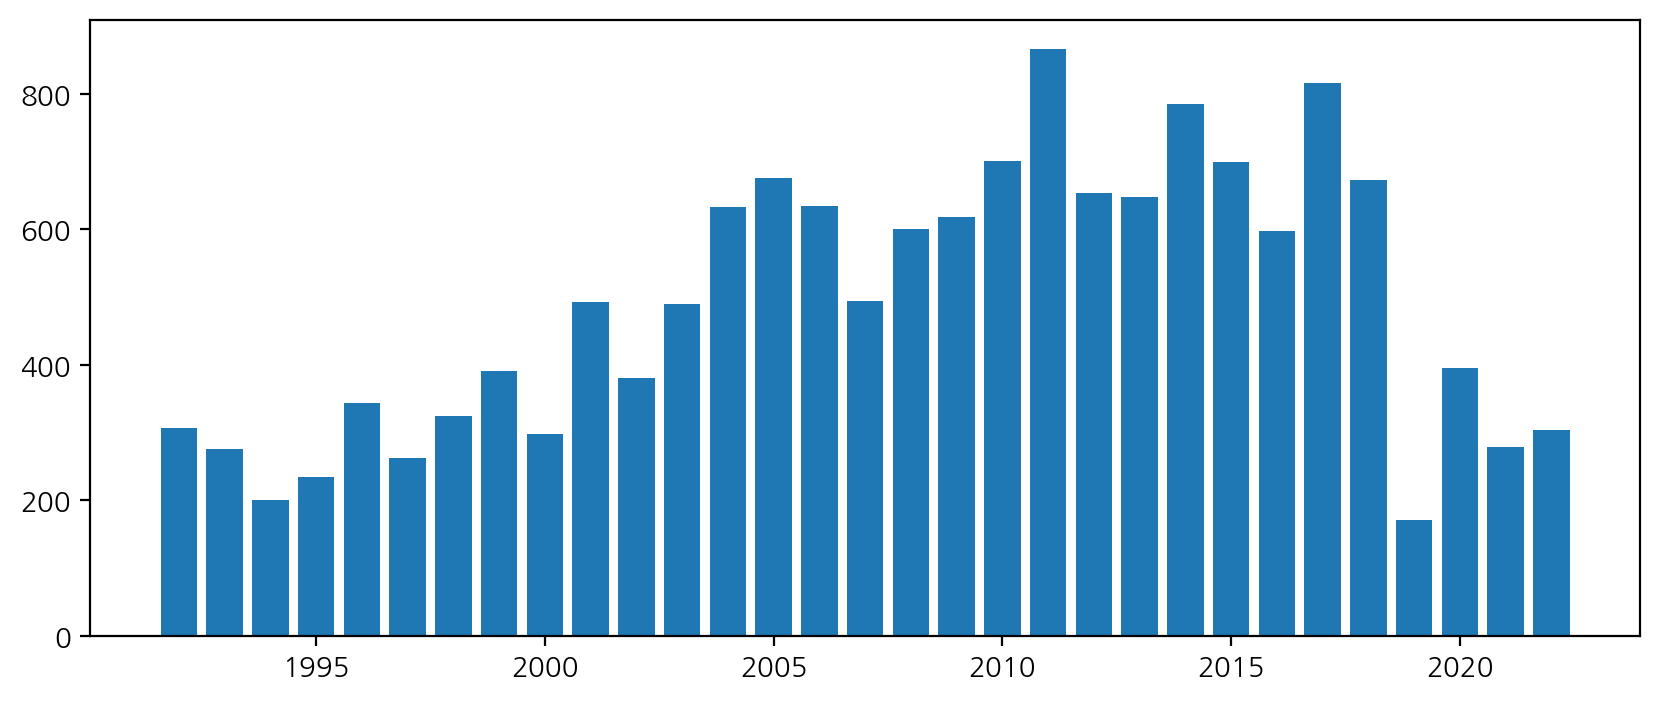

In [1346]:
cate_analysis(apart_cat, '준공연도')

#### 3) 건물형태

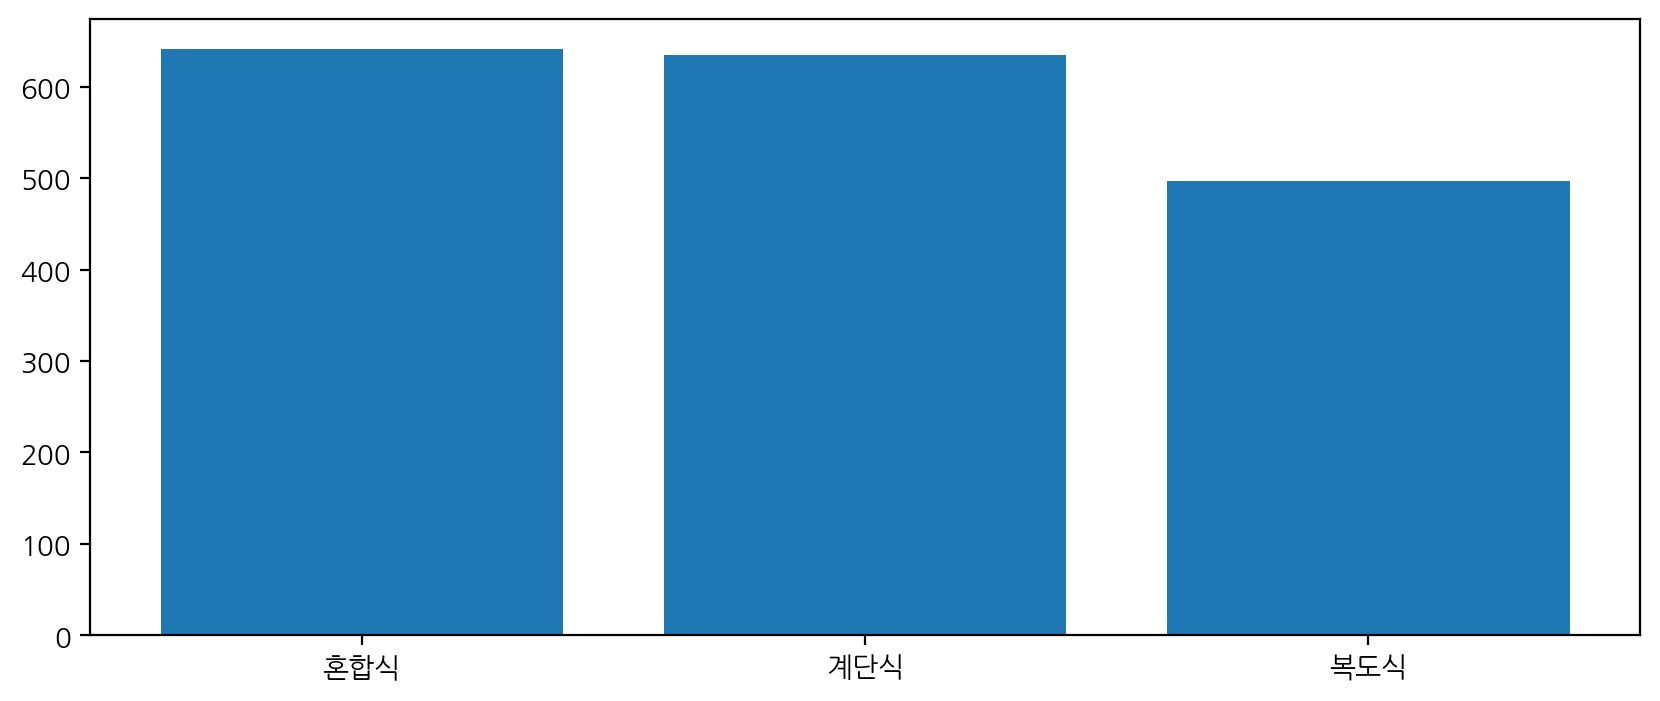

In [1349]:
cate_analysis(apart_cat, '건물형태')

#### 4) 난방방식

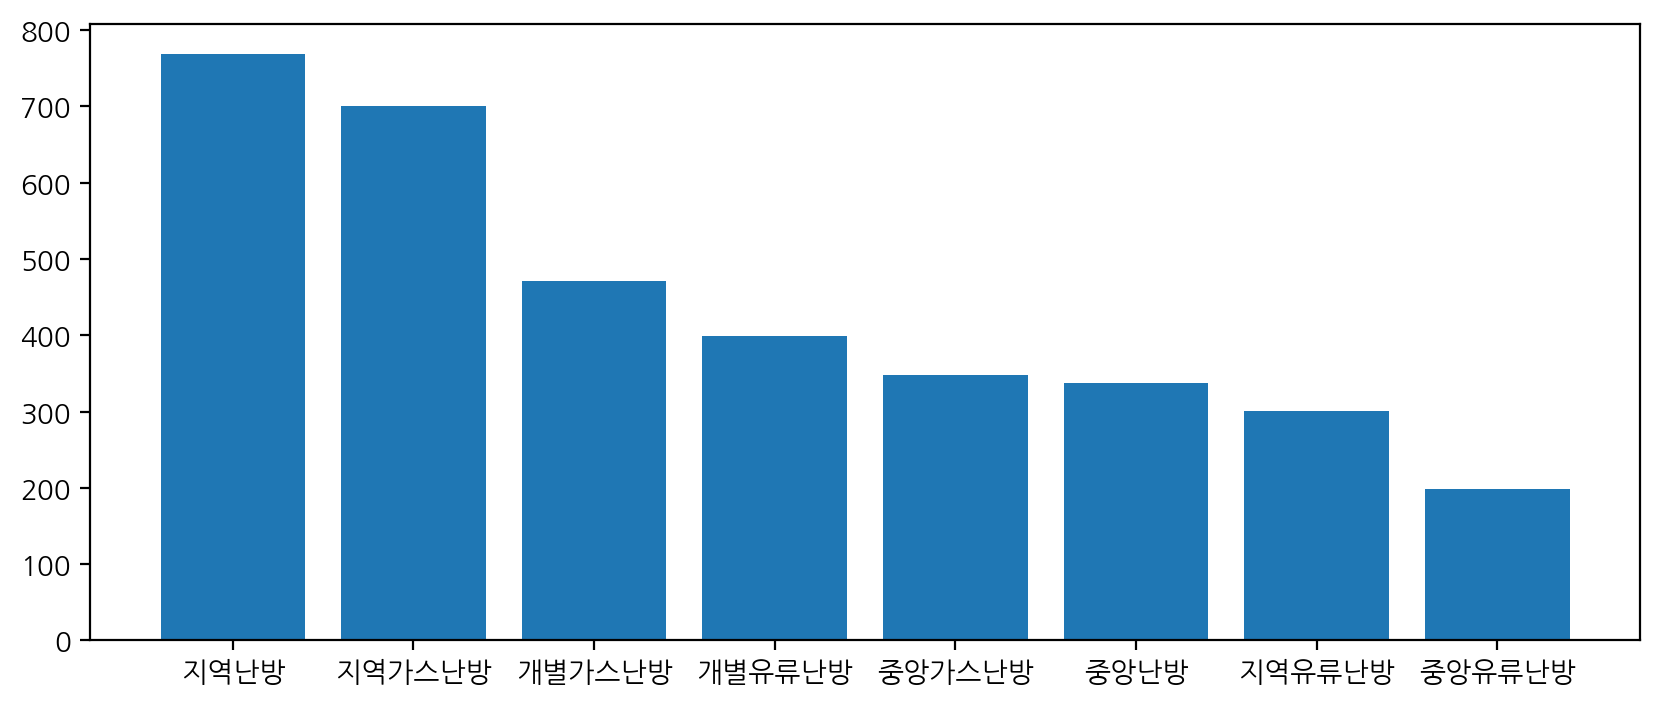

In [1352]:
cate_analysis(apart_cat, '난방방식')

#### 5) 승강기설치여부

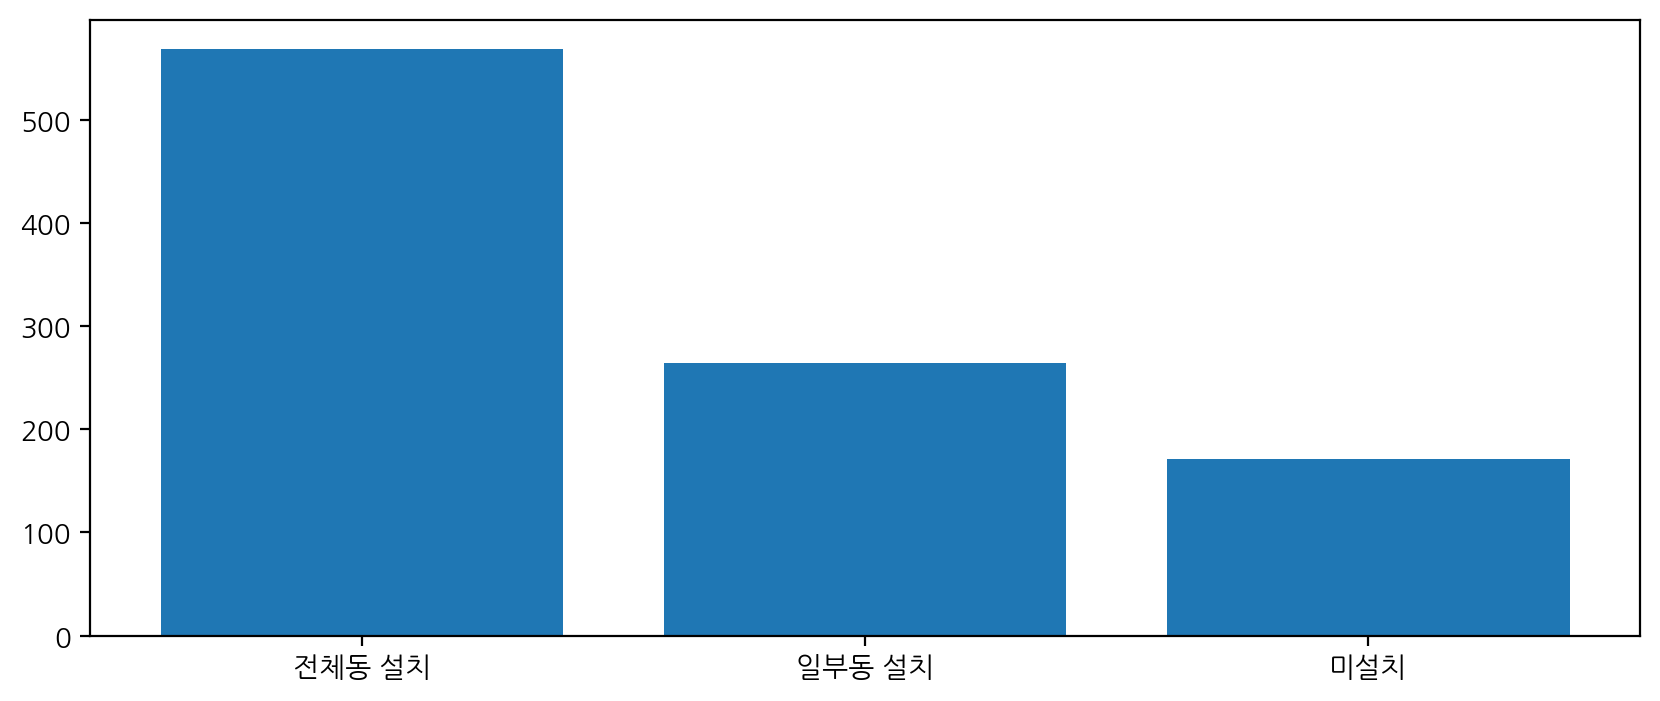

In [1355]:
cate_analysis(apart_cat, '승강기설치여부')

## 5. 추가 전처리

- '난방방식', '승강기설치여부' 두 변수에 대해서 적은 수의 범주로 묶는 작업을 진행합니다.
- '단지코드'는 개별적인 값이므로 예측과 관련이 없으니 제거합니다.
- '지역' 변수는 지역별 특성을 고려하기에는 너무 세분화 되어 있고, 특징으로 통합하기 어려우므로 제거합니다.

### (1) 난방방식

- '난방방식' 변수의 값을 다음과 같이 변경하여 세 개의 범줏값만 갖게 합니다.
    - 개별가스난방 → 개별
    - 개별유류난방 → 개별
    - 지역난방 → 지역
    - 지역가스난방 → 지역
    - 지역유류난방 → 지역
    - 중앙가스난방 → 중앙
    - 중앙난방 → 중앙
    - 중앙유류난방 → 중앙

In [1359]:
apart['난방방식'] = apart['난방방식'].map({'개별가스난방': '개별', '개별유류난방': '개별', '지역난방': '지역', 
                                  '지역가스난방': '지역', '지역유류난방': '지역', '중앙가스난방': '중앙',
                                  '중앙난방': '중앙', '중앙유류난방': '중앙'})
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
0,C0001,78,서울,2013,계단식,개별,전체동 설치,109,6023.7683,5.696200e+07,642930.000000,0,0,0,0,2,0,0
1,C0002,35,서울,2013,복도식,개별,전체동 설치,35,1569.1668,6.306200e+07,470100.000000,0,2,0,0,0,0,0
2,C0003,88,서울,2013,계단식,개별,전체동 설치,88,7180.1396,7.219000e+07,586540.000000,0,0,0,0,4,0,0
3,C0004,477,서울,2014,복도식,지역,전체동 설치,943,47058.9273,1.015167e+08,950305.000000,0,0,0,0,1,0,2
4,C0006,15,서울,2013,복도식,개별,전체동 설치,21,543.0268,5.522750e+07,340148.333333,3,3,0,0,0,0,0


### (2) 승강기설치여부

- '승강기설치여부' 변수의 값을 다음과 같이 변경하여 0, 1 값을 갖게 합니다.
    - 전체동 설치 → 1
    - 일부동 설치 → 0
    - 미설치 → 0

In [1362]:
apart['승강기설치여부'] = apart['승강기설치여부'].map({'전체동 설치': 1, '일부동 설치': 0, '미설치': 0})
apart.head()

,단지코드,총세대수,지역,준공연도,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80
0,C0001,78,서울,2013,계단식,개별,1,109,6023.7683,5.696200e+07,642930.000000,0,0,0,0,2,0,0
1,C0002,35,서울,2013,복도식,개별,1,35,1569.1668,6.306200e+07,470100.000000,0,2,0,0,0,0,0
2,C0003,88,서울,2013,계단식,개별,1,88,7180.1396,7.219000e+07,586540.000000,0,0,0,0,4,0,0
3,C0004,477,서울,2014,복도식,지역,1,943,47058.9273,1.015167e+08,950305.000000,0,0,0,0,1,0,2
4,C0006,15,서울,2013,복도식,개별,1,21,543.0268,5.522750e+07,340148.333333,3,3,0,0,0,0,0


### (3) 추가 변수: 인구밀도

In [1365]:
pop = {
    '서울': 9400,
    '부산울산': 4390,
    '대구경북': 4971,
    '경기': 13781,
    '광주전남': 3231,
    '강원': 1525,
    '충북': 1627,
    '대전충남': 3678,
    '경남': 3267,
    '제주': 677,
    '전북': 1768,
    '세종': 387
}

pop_dens = {
    '서울': 15533,
    '부산울산': 3517.95,
    '대구경북': 1395.28,
    '경기': 1351,
    '광주전남': 1389.09,
    '강원': 91,
    '충북': 220,
    '대전충남': 1185.96,
    '경남': 310,
    '제주': 366,
    '전북': 219,
    '세종': 833
}
apart['인구수'] = apart['지역'].map(pop)
apart['인구밀도'] = apart['지역'].map(pop_dens)
apart.drop(columns = ['지역', '준공연도'], inplace=True)

- 최종 데이터를 확인합니다.

In [1368]:
apart.head()

,단지코드,총세대수,건물형태,난방방식,승강기설치여부,실차량수,총면적,임대보증금,임대료,면적10_20,면적20_30,면적30_40,면적40_50,면적50_60,면적60_70,면적70_80,인구수,인구밀도
0,C0001,78,계단식,개별,1,109,6023.7683,5.696200e+07,642930.000000,0,0,0,0,2,0,0,9400,15533.0
1,C0002,35,복도식,개별,1,35,1569.1668,6.306200e+07,470100.000000,0,2,0,0,0,0,0,9400,15533.0
2,C0003,88,계단식,개별,1,88,7180.1396,7.219000e+07,586540.000000,0,0,0,0,4,0,0,9400,15533.0
3,C0004,477,복도식,지역,1,943,47058.9273,1.015167e+08,950305.000000,0,0,0,0,1,0,2,9400,15533.0
4,C0006,15,복도식,개별,1,21,543.0268,5.522750e+07,340148.333333,3,3,0,0,0,0,0,9400,15533.0


## 6. 데이터 셋 저장

- joblib.dump() 함수를 사용하여 최종 데이터 셋을 파일로 저장합니다.
- 파일 이름은 base_data2.pkl로 합니다.

In [1371]:
# 파일로 저장
joblib.dump(apart, path+'base_data2.pkl')

['./base_data2.pkl']